# CME Futures Case Study: Feasibility Analysis

This notebook tests whether the CME futures dataset can deliver on the strategy
declared in `config/setup.yaml`. `setup.yaml` is the canonical, hand-curated
source of truth: universe (30 products across seven sectors), decision cadence,
cost model, labels, sweep grid, and evaluation protocol. This notebook does
not write it. Instead, it produces the evidence that justifies its values:
data coverage across products and time, return distributions at the candidate
horizons relative to transaction costs, the futures return decomposition that
makes carry a payoff component, and a walk-forward fold demonstration. Findings
persist to `config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify the data delivers what `setup.yaml` assumes (30 products, coverage, holdout)
- Decompose futures returns into spot + roll components and document the sign convention
- Test whether typical price moves exceed transaction costs at candidate horizons
- Demonstrate the walk-forward structure declared in `setup.yaml::evaluation`
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2-6.6

## Prerequisites

- CME futures data available via `load_cme_futures()` (Databento daily settlements)
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of futures roll mechanics and walk-forward CV (Section 6.5)

In [1]:
"""CME Futures Case Study: Feasibility Analysis."""

import json
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml
from scipy import stats

from data import load_cme_futures
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
CASE_STUDY_ID = "cme_futures"
START_DATE = "2011-01-01"  # Futures data starts 2011
MAX_SYMBOLS = 0

## Configuration

In [3]:
CASE_DIR = get_case_study_dir("cme_futures")
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
START_DATE = "2011-01-01"
END_DATE = "2025-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])

---

## Section A: Orientation (Section 6.2)

CME futures provide leveraged exposure across asset classes (equity indices,
rates, energy, metals, currencies, agriculture, livestock) with a return
structure that splits into spot movement and roll yield. The strategy operates
at a weekly cadence on 30 front-month continuous contracts.

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Are all 30 declared products present across the sample period?
- **Returns**: How do futures returns decompose into spot and roll components?
- **Costs**: Do typical moves exceed the 5 bps round-trip floor at daily and weekly horizons?
- **Evaluation**: Does the data support 5 walk-forward folds with the declared train/val/holdout split?

---

## Section B: Universe and Cost Feasibility (Sections 6.3-6.4)

### B.1 Load and Verify the Data

The loader returns daily settlement data per product and tenor. `tenor == 0`
is the front-month contract; deferred contracts (`tenor == 1, 2, ...`) carry
the term structure used in Chapter 7 carry features. For feasibility analysis
we use the front-month `adj_close`, which is the roll-continuous
(back-adjusted) settlement series --- `adj_close == raw_close * cum_ratio`, so
roll gaps are removed and return magnitudes reflect genuine price moves rather
than roll discontinuities. The contemporaneous traded level (`raw_close`) is
what carries roll jumps; Chapter 7 uses `raw_close` and the deferred tenors to
construct explicit carry and roll-yield features.

In [4]:
futures_data = load_cme_futures(start_date=START_DATE, end_date=END_DATE)

front = (
    futures_data.filter(pl.col("tenor") == 0)
    .select(["product", "session_date", "adj_close", "volume"])
    .sort(["product", "session_date"])
)

n_products_in_data = front["product"].n_unique()
n_dates = front["session_date"].n_unique()
print(f"Loaded {n_products_in_data} products, {len(front):,} rows")
print(f"Period: {front['session_date'].min()} to {front['session_date'].max()}")
print(f"Distinct session dates: {n_dates}")

Loaded 30 products, 113,506 rows
Period: 2011-01-03 to 2025-12-31
Distinct session dates: 3874


### B.2 Universe Verification

`setup.yaml::universe.product_groups` declares 30 CME root symbols across
seven sectors. We verify every declared product is present in the data and
report coverage per product (no point-in-time eligibility filter applies to
futures --- the universe is fixed by exchange contract availability).

In [5]:
declared_groups = SETUP["universe"]["product_groups"]
declared_products = sorted(p for products in declared_groups.values() for p in products)
n_products_declared = SETUP["universe"]["n_products"]

actual_products = sorted(front["product"].unique().to_list())
missing = sorted(set(declared_products) - set(actual_products))
extra = sorted(set(actual_products) - set(declared_products))

assert not missing, f"Declared but missing from data: {missing}"
print(f"Declared products: {n_products_declared}")
print(f"Found in data: {len(actual_products)}")
if extra:
    print(f"Extra in data (not in setup.yaml): {extra}")

Declared products: 30
Found in data: 30


In [6]:
# Coverage per product: number of session dates and earliest/latest dates
coverage = (
    front.group_by("product")
    .agg(
        pl.col("session_date").n_unique().alias("n_days"),
        pl.col("session_date").min().alias("first_date"),
        pl.col("session_date").max().alias("last_date"),
    )
    .sort("n_days")
)

print("\nCoverage by product (sorted ascending):")
coverage


Coverage by product (sorted ascending):


product,n_days,first_date,last_date
str,u32,date,date
"""RTY""",2191,2017-07-10,2025-12-31
"""LE""",3764,2011-01-03,2025-12-30
"""HE""",3765,2011-01-03,2025-12-30
"""GF""",3765,2011-01-03,2025-12-30
"""ZM""",3773,2011-01-03,2025-12-30
…,…,…,…
"""PL""",3869,2011-01-03,2025-12-31
"""HO""",3869,2011-01-03,2025-12-31
"""CL""",3869,2011-01-03,2025-12-31


All declared products have meaningful coverage across the 2011-2025 sample.
Some products start later than 2011-01-01 (driven by Databento contract-listing
dates); the walk-forward folds operate on whatever coverage exists per product.

### B.3 Trading Cost Analysis: Horizon Feasibility

A fundamental question for any trading strategy is: **at which holding periods
do typical price moves exceed transaction costs?**

Futures have low per-trade costs (~3-5 bps round-trip for liquid contracts ---
commission + half-tick spread). We test both daily and weekly horizons against
a 5 bps round-trip cost floor.

In [7]:
# Daily front-month returns on the roll-adjusted series (adj_close): roll gaps are
# removed so feasibility-scale statistics reflect genuine price moves, not roll
# discontinuities. Ch7 features compute their own returns from adj_close explicitly.
daily_returns = (
    front.with_columns(
        (pl.col("adj_close") / pl.col("adj_close").shift(1) - 1).over("product").alias("return")
    )
    .filter(pl.col("return").is_not_null())
    .select(["product", "session_date", "return"])
)

# Weekly returns: Friday-close to Friday-close (the declared decision cadence)
weekly = (
    front.with_columns(pl.col("session_date").dt.strftime("%G-W%V").alias("week"))
    .group_by(["product", "week"])
    .agg(
        pl.col("adj_close").last().alias("adj_close"),
        pl.col("session_date").max().alias("session_date"),
    )
    .sort(["product", "session_date"])
)
weekly_returns = weekly.with_columns(
    (pl.col("adj_close") / pl.col("adj_close").shift(1) - 1).over("product").alias("return")
).filter(pl.col("return").is_not_null())

print(f"Daily returns: {len(daily_returns):,} observations")
print(f"Weekly returns: {len(weekly_returns):,} observations")

Daily returns: 113,476 observations
Weekly returns: 23,117 observations


#### Summary Statistics by Horizon

In [8]:
daily_abs = daily_returns["return"].abs().to_numpy()
weekly_abs = weekly_returns["return"].abs().to_numpy()

# Cost reference: 5 bps round-trip for liquid CME futures (commission + half-tick spread)
ROUND_TRIP_COST_BPS = 5
ROUND_TRIP_COST = ROUND_TRIP_COST_BPS / 10_000  # 0.0005


def compute_return_stats(data: np.ndarray, horizon: str) -> dict:
    """Compute return distribution statistics for a given horizon."""
    return {
        "horizon": horizon,
        "median_pct": float(np.median(data)) * 100,
        "mean_pct": float(np.mean(data)) * 100,
        "std_pct": float(np.std(data)) * 100,
        "p75_pct": float(np.percentile(data, 75)) * 100,
        "p95_pct": float(np.percentile(data, 95)) * 100,
        "pct_above_5bps": float((data > ROUND_TRIP_COST).mean()) * 100,
    }


return_stats = pl.DataFrame(
    [
        compute_return_stats(daily_abs, "Daily"),
        compute_return_stats(weekly_abs, "Weekly"),
    ]
)

return_stats.select(
    [
        "horizon",
        pl.col("median_pct").round(2).alias("median %"),
        pl.col("mean_pct").round(2).alias("mean %"),
        pl.col("std_pct").round(2).alias("std %"),
        pl.col("p75_pct").round(2).alias("p75 %"),
        pl.col("p95_pct").round(2).alias("p95 %"),
        pl.col("pct_above_5bps").round(1).alias("> 5bps %"),
    ]
)

horizon,median %,mean %,std %,p75 %,p95 %,> 5bps %
str,f64,f64,f64,f64,f64,f64
"""Daily""",0.52,0.88,1.11,1.15,2.87,91.6
"""Weekly""",1.22,1.97,2.37,2.61,6.38,96.3


**Fraction of moves exceeding cost thresholds**

In [9]:
COST_THRESHOLDS_BPS = [1, 5, 10, 20, 50]
cost_exceedance = []
for horizon, data in [("Daily", daily_abs), ("Weekly", weekly_abs)]:
    row = {"horizon": horizon}
    for cost_bps in COST_THRESHOLDS_BPS:
        row[f"{cost_bps}_bps"] = float((data > cost_bps / 10_000).mean()) * 100
    cost_exceedance.append(row)

cost_df = pl.DataFrame(cost_exceedance)
cost_df.select(
    [
        "horizon",
        pl.col("1_bps").round(1).alias("1 bps %"),
        pl.col("5_bps").round(1).alias("5 bps %"),
        pl.col("10_bps").round(1).alias("10 bps %"),
        pl.col("20_bps").round(1).alias("20 bps %"),
        pl.col("50_bps").round(1).alias("50 bps %"),
    ]
)

horizon,1 bps %,5 bps %,10 bps %,20 bps %,50 bps %
str,f64,f64,f64,f64,f64
"""Daily""",98.0,91.6,85.2,74.5,51.3
"""Weekly""",99.3,96.3,93.1,87.7,73.9


#### Visualize Return Distributions

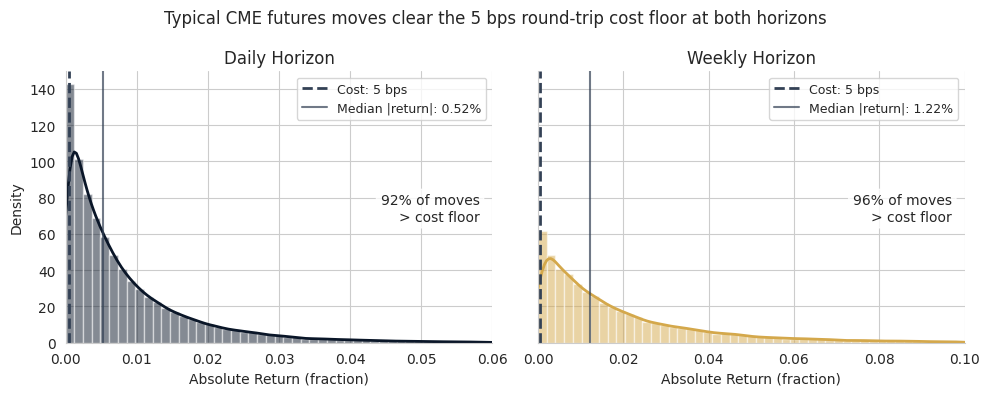

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

horizons = [
    ("Daily", daily_abs, COLORS["blue"]),
    ("Weekly", weekly_abs, COLORS["amber"]),
]

for ax, (label, data, color) in zip(axes, horizons, strict=False):
    xlim = 0.06 if label == "Daily" else 0.10
    data_clipped = data[data < xlim]
    bins = np.linspace(0, xlim, 50)
    ax.hist(data_clipped, bins=bins, density=True, alpha=0.5, color=color, edgecolor="white")

    if len(data_clipped) > 100:
        kde = stats.gaussian_kde(data_clipped, bw_method=0.1)
        x_grid = np.linspace(0, xlim, 200)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    ax.axvline(
        ROUND_TRIP_COST,
        color=COLORS["neutral"],
        linestyle="--",
        linewidth=2,
        label=f"Cost: {ROUND_TRIP_COST_BPS} bps",
    )

    median_val = float(np.median(data))
    frac_above = float((data > ROUND_TRIP_COST).mean())
    ax.axvline(
        median_val,
        color=COLORS["neutral"],
        linestyle="-",
        linewidth=1.5,
        alpha=0.7,
        label=f"Median |return|: {median_val * 100:.2f}%",
    )

    # Annotation placed in the empty right tail so it never overlaps the legend.
    ax.text(
        0.97,
        0.55,
        f"{frac_above:.0%} of moves\n> cost floor",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_title(f"{label} Horizon")
    ax.set_xlabel("Absolute Return (fraction)")
    ax.set_xlim(0, xlim)
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Density")
fig.suptitle("Typical CME futures moves clear the 5 bps round-trip cost floor at both horizons")
sns.despine()
fig.tight_layout()
plt.show()

#### Return Decomposition: Spot + Roll

Futures returns decompose as:

$$R_{\text{total}} = R_{\text{spot}} + R_{\text{roll}}$$

Let $F_1$ be the front-month price and $F_2$ the first deferred contract. The
term structure slope is:

$$s_t = \frac{F_2 - F_1}{F_1}$$

For a long position that rolls from $F_1$ into $F_2$, the roll component is
approximately:

$$R_{\text{roll}} \approx -s_t$$

- **Contango** ($F_2 > F_1$): $s_t > 0$ so $R_{\text{roll}} < 0$ (longs lose on roll)
- **Backwardation** ($F_2 < F_1$): $s_t < 0$ so $R_{\text{roll}} > 0$ (longs gain on roll)

This is why carry signals are a payoff component, not just a cost: the term
structure slope predicts the roll contribution at the next rebalance. Chapter 7
constructs explicit carry features using $F_1$ and $F_2$ from the same loader.

### B.4 Feasibility Ratio

A simple edge-to-cost ratio confirms that typical weekly signal magnitude
comfortably exceeds transaction costs before proceeding further. We use the
weekly horizon because `setup.yaml::decision.cadence = weekly_friday_close`.

In [11]:
median_weekly_abs_return = float(np.median(weekly_abs))
feasibility_ratio = median_weekly_abs_return / ROUND_TRIP_COST
print(
    f"Median weekly |return|: {median_weekly_abs_return:.4f} "
    f"({median_weekly_abs_return * 10000:.1f} bps)"
)
print(f"Round-trip cost: {ROUND_TRIP_COST:.4f} ({ROUND_TRIP_COST_BPS} bps)")
print(f"Edge-to-cost ratio: {feasibility_ratio:.1f}x")
print(f"Assessment: {'PROCEED' if feasibility_ratio > 1.0 else 'KILL -- edge too thin'}")

Median weekly |return|: 0.0122 (122.0 bps)
Round-trip cost: 0.0005 (5 bps)
Edge-to-cost ratio: 24.4x
Assessment: PROCEED


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml` that the
feasibility evidence above supports. They are justified here, not in the YAML.

### C.1 Decision Cadence

`setup.yaml::decision.cadence = weekly_friday_close` with Monday-open execution
delay. Weekly cadence is the natural choice for futures carry: the dominant
payoff component (roll yield) accrues continuously regardless of rebalancing
frequency, so more frequent trading adds turnover without capturing more carry.
The cost analysis above confirms that weekly absolute returns comfortably
exceed the 5 bps round-trip floor on nearly all observations.

Daily rebalancing is feasible from a cost perspective (the majority of daily
moves also exceed 5 bps) but offers no structural advantage for carry-driven
signals. Monthly cadence would lengthen the carry capture window but shrink
the effective sample size to ~180 monthly decision dates over ~15 years ---
weekly gives ~780, which is meaningful for cross-sectional rank statistics
on a narrow 30-product cross-section.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints --- if any triggers, the strategy
is abandoned or substantially reworked. The thresholds below are anchored to
the feasibility evidence above (cost-exceedance and edge-to-cost analysis):

- **KC1 (IC floor)**: Combined IC (carry + momentum) < 0.03 with t-stat < 5.0
  across folds. Gate: Chapter 8 feature evaluation and Chapter 11-12 modeling.
- **KC2 (carry sign)**: Traditional long-backwardation carry becomes
  profitable across the full sample --- would suggest any "inverted carry"
  finding is a regime-specific artifact rather than a stable edge. Gate:
  Chapter 11-12 fold stability.
- **KC3 (cost dominance)**: Round-trip cost exceeds the median weekly absolute
  return for >50% of the universe. B.4 above tests this gate on the front-month
  aggregate; per-product cost dominance is tested in Chapter 18.

### C.3 Mapping Class

`setup.yaml::mapping.class = long_short_carry_rank` with
`position_state_space: long_short` and `sizing: equal_risk_or_notional`.
Long-short is appropriate for futures because (a) shorting is structurally
symmetric --- futures contracts have no borrow cost or hard-to-borrow
restrictions, so the short side is as cheap as the long side; (b) the carry
signal is naturally cross-sectional (rank-based: long high-carry, short
low-carry), which only works in a long-short construction; (c) long-only
would forfeit the contango leg of the carry trade. Equal-risk (vol-scaled)
sizing is the minimal-assumption rule for a cross-asset universe spanning
rates, equities, energy, and ags, where notional-equal weighting would
concentrate risk in the high-vol contracts (energy, ags). Chapter 17
explores alternative allocators via the `backtest.sweep.allocators` grid
in `setup.yaml`.

**Narrow cross-section caveat**: With 30 products in 7 sectors, quintile
buckets contain only 6 instruments each. Cross-sectional rank signals have
limited statistical power; time-series signals (per-product carry, momentum)
carry independent information and are evaluated alongside the cross-section
in Chapter 11-12.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify that the data supports the walk-forward design declared in
`setup.yaml::evaluation` (`n_splits`, `train_size`, `val_size`, `holdout_start`).

### D.1 Effective Sample Size and Data Coverage

In [12]:
n_weeks = weekly["week"].n_unique()
first_week = weekly["week"].min()
last_week = weekly["week"].max()
n_years = n_weeks / 52

print("Data Coverage:")
print(f"  Period: {first_week} to {last_week}")
print(f"  Weekly decision dates: {n_weeks}")
print(f"  Approx years: {n_years:.1f}")

Data Coverage:
  Period: 2011-W01 to 2026-W01
  Weekly decision dates: 783
  Approx years: 15.1


### D.2 Walk-Forward Fold Demonstration

`case_studies/utils/cv_window.py` owns the operational splits; this cell
reproduces the fold boundaries from canonical `setup.yaml` parameters to verify
the data supports the declared design. Each fold has:

- **Train period**: `setup.yaml::evaluation.train_size` (8Y rolling)
- **Val period**: `setup.yaml::evaluation.val_size` (1Y)
- **Purge gap**: 1 week between train end and val start (matches the 5D
  `labels.buffer` for the fwd_ret_5d primary label at weekly cadence)

In [13]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
train_years = 8
data_start_year = 2011
holdout_start_year = int(HOLDOUT_START[:4])

splits = []
for fold_idx in range(n_splits_declared):
    test_year = data_start_year + train_years + fold_idx
    train_start = test_year - train_years
    train_end = test_year - 1
    splits.append(
        {
            "fold": fold_idx + 1,
            "train_start": f"{train_start}-01-01",
            "train_end": f"{train_end}-12-31",
            "test_start": f"{test_year}-01-01",
            "test_end": f"{test_year}-12-31",
            "purge_weeks": 1,
        }
    )

print(f"Generated {len(splits)} walk-forward folds")

assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
last_test_end = splits[-1]["test_end"]
print(f"Last fold test end: {last_test_end}  |  Holdout start: {HOLDOUT_START}")
assert last_test_end < HOLDOUT_START, (
    f"Last fold ({last_test_end}) overlaps holdout ({HOLDOUT_START})"
)

Generated 5 walk-forward folds
Last fold test end: 2023-12-31  |  Holdout start: 2024-01-01


**Walk-forward fold summary:**

In [14]:
splits_df = pl.DataFrame(splits)
splits_df

fold,train_start,train_end,test_start,test_end,purge_weeks
i64,str,str,str,str,i64
1,"""2011-01-01""","""2018-12-31""","""2019-01-01""","""2019-12-31""",1
2,"""2012-01-01""","""2019-12-31""","""2020-01-01""","""2020-12-31""",1
3,"""2013-01-01""","""2020-12-31""","""2021-01-01""","""2021-12-31""",1
4,"""2014-01-01""","""2021-12-31""","""2022-01-01""","""2022-12-31""",1
5,"""2015-01-01""","""2022-12-31""","""2023-01-01""","""2023-12-31""",1


#### Universe Breadth per Fold

We verify that each fold has adequate cross-sectional breadth by counting
products with data in each test year. Cross-sectional rank signals benefit
from coverage on the full 30-product universe.

In [15]:
fold_breadth = []
for split in splits:
    test_year = int(split["test_start"][:4])
    n_present = front.filter(pl.col("session_date").dt.year() == test_year)["product"].n_unique()
    fold_breadth.append({"fold": split["fold"], "test_year": test_year, "n_present": n_present})

fold_breadth_df = pl.DataFrame(fold_breadth)
print("Products present per fold test year:")
fold_breadth_df

Products present per fold test year:


fold,test_year,n_present
i64,i64,i64
1,2019,30
2,2020,30
3,2021,30
4,2022,30
5,2023,30


All five folds carry the full 30-product universe (or close to it), which is
sufficient for cross-sectional ranking on this narrow universe. Quintile
buckets remain at ~6 instruments each across folds.

---

## Section E: Derived Artifacts

The CME futures universe is fixed by exchange contract availability --- there
is no point-in-time eligibility filter to materialize (the closest analog is
the per-product coverage table in B.2, which is informational). The one
decision-relevant artifact this notebook produces is the feasibility report
in Section F. All other strategy parameters live in `config/setup.yaml`.

---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. Setup.yaml is not regenerated here --- it is the hand-curated
source of truth, and this notebook reads it.

In [16]:
median_d_abs_pct = float(np.median(daily_abs) * 100)
median_w_abs_pct = float(np.median(weekly_abs) * 100)
frac_d_above_5 = float((daily_abs > ROUND_TRIP_COST).mean())
frac_w_above_5 = float((weekly_abs > ROUND_TRIP_COST).mean())
n_products_present_min = int(min(fb["n_present"] for fb in fold_breadth))
n_products_present_max = int(max(fb["n_present"] for fb in fold_breadth))
n_folds_generated = int(len(splits))

print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.n_products = {SETUP['universe']['n_products']}")
print(
    f"  -> products in data: {n_products_in_data}; "
    f"per-fold min={n_products_present_min}, max={n_products_present_max}"
)

print()
print(f"decision.cadence = {SETUP['decision']['cadence']}")
print(
    f"  -> median |weekly return| = {median_w_abs_pct:.2f}%; "
    f"{frac_w_above_5 * 100:.0f}% exceed 5bps RT"
)

print()
print(f"costs.class = {SETUP['costs']['class']}")
print(f"  -> at 5bps RT: edge-to-cost = {feasibility_ratio:.1f}x at weekly horizon")
print(f"  -> daily moves > 5bps: {frac_d_above_5 * 100:.0f}%")
print(f"  -> weekly moves > 5bps: {frac_w_above_5 * 100:.0f}%")

print()
print(f"mapping.class = {SETUP['mapping']['class']}")
print(f"  -> position_state_space = {SETUP['mapping']['position_state_space']}")
print(f"  -> sizing = {SETUP['mapping']['sizing']}")

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(
    f"  -> median |weekly return| = {median_w_abs_pct:.2f}% = "
    f"{(median_w_abs_pct / 100) / ROUND_TRIP_COST:.0f}x a 5bps cost"
)

print()
print(f"labels.variants = {SETUP['labels']['variants']}")
print("  -> 21d horizon supports longer-carry capture; same cost floor applies")

print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"  -> generated {n_folds_generated} folds; declared count matches")
print(
    f"  -> holdout {SETUP['evaluation']['holdout_start']} "
    f"to {SETUP['evaluation']['holdout_end']}; "
    f"last test ends {splits[-1]['test_end']}"
)

Setup.yaml knobs vs feasibility evidence

universe.n_products = 30
  -> products in data: 30; per-fold min=30, max=30

decision.cadence = weekly_friday_close
  -> median |weekly return| = 1.22%; 96% exceed 5bps RT

costs.class = material
  -> at 5bps RT: edge-to-cost = 24.4x at weekly horizon
  -> daily moves > 5bps: 92%
  -> weekly moves > 5bps: 96%

mapping.class = long_short_carry_rank
  -> position_state_space = long_short
  -> sizing = equal_risk_or_notional

labels.primary = fwd_ret_5d
  -> median |weekly return| = 1.22% = 24x a 5bps cost

labels.variants = ['fwd_ret_21d']
  -> 21d horizon supports longer-carry capture; same cost floor applies

evaluation.n_splits = 5
  -> generated 5 folds; declared count matches
  -> holdout 2024-01-01 to 2025-12-31; last test ends 2023-12-31


### Persist Feasibility Findings

In [17]:
feasibility_report = {
    "case_study_id": "cme_futures",
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE},
    "universe": {
        "n_products_declared": int(SETUP["universe"]["n_products"]),
        "n_products_in_data": int(n_products_in_data),
        "n_products_per_fold_min": n_products_present_min,
        "n_products_per_fold_max": n_products_present_max,
    },
    "return_distribution_abs_pct": {
        "daily_median": median_d_abs_pct,
        "weekly_median": median_w_abs_pct,
    },
    "cost_reference_bps_round_trip": ROUND_TRIP_COST_BPS,
    "cost_exceedance_at_5bps_pct": {
        "daily": frac_d_above_5 * 100,
        "weekly": frac_w_above_5 * 100,
    },
    "feasibility_ratio_weekly_at_5bps": float(feasibility_ratio),
    "walk_forward": {
        "n_folds_generated": n_folds_generated,
        "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
        "holdout_start": HOLDOUT_START,
        "holdout_end": HOLDOUT_END,
        "last_test_end": splits[-1]["test_end"],
    },
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2)
print(f"Written: {report_path}")

Written: /tmp/claude-1000/-home-stefan-ml4t-agents/b7489809-543c-45e3-851e-71c7f0c220d1/scratchpad/ml4t-out/cme_futures/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Universe**: All 30 declared CME products are present; per-fold breadth
   holds at the full universe across the 5 walk-forward folds. The narrow
   cross-section (~6 per quintile) is the binding statistical constraint, not
   coverage.
2. **Return decomposition**: Futures returns split into spot + roll. Roll
   yield ($R_{\text{roll}} \approx -s_t$) is a payoff component driven by the
   term structure slope --- contango hurts longs, backwardation helps them.
   Chapter 7 constructs explicit carry features from $F_1, F_2$.
3. **Cost feasibility**: Both daily and weekly horizons clear the 5 bps
   round-trip threshold by wide margins. Edge-to-cost ratio at the weekly
   horizon is comfortably above 1.0 on raw return magnitudes, so KC3 (cost
   dominance) is cleared before training begins.
4. **Cadence**: Weekly Friday-close with Monday-open execution is the natural
   choice for carry --- roll yield accrues continuously, so faster
   rebalancing adds turnover without capturing more carry.
5. **Mapping**: Long-short equal-risk on cross-sectional carry ranks is the
   minimal-assumption baseline; allocator variants sweep in
   `setup.yaml::backtest.sweep.allocators` (explored in Chapter 17--18).
6. **Evaluation**: 5 walk-forward folds with verified holdout separation
   (`evaluation.holdout_start = 2024-01-01` enforced).

**Artifacts written**:
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running this notebook.

**Next**: Chapter 7 creates labels at the 5-day primary and 21-day variant
horizons declared in `setup.yaml::labels`.